In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks, iirnotch
from scipy.interpolate import CubicSpline

In [19]:
path=r"C:\Users\Adyty\Documents\Farid ITS\TriaGo\GUI\Data_raw_20260724_161510.csv"
df=pd.read_csv(path, sep=',', header=0)
df.head()

,Time (s),PPG_Red,PPG_IR,PPG_Green,ECG,Temp_Ambient,Temp_Object
0,0.0000,29990,33721,90,1400,23.23,23.58
1,0.0025,29986,33724,80,1753,23.23,23.58
2,0.0050,29998,33729,82,1433,23.23,23.58
3,0.0075,29993,33735,88,1099,23.23,23.58
4,0.0100,30004,33726,85,949,23.23,23.58


In [20]:
ecg = df['ECG'].values
time = df['Time (s)'].values
red = df['PPG_Red'].values
ir = df['PPG_IR'].values
fs = int(np.round(len(ecg) / (time[-1] - time[0])))
print(fs)

400


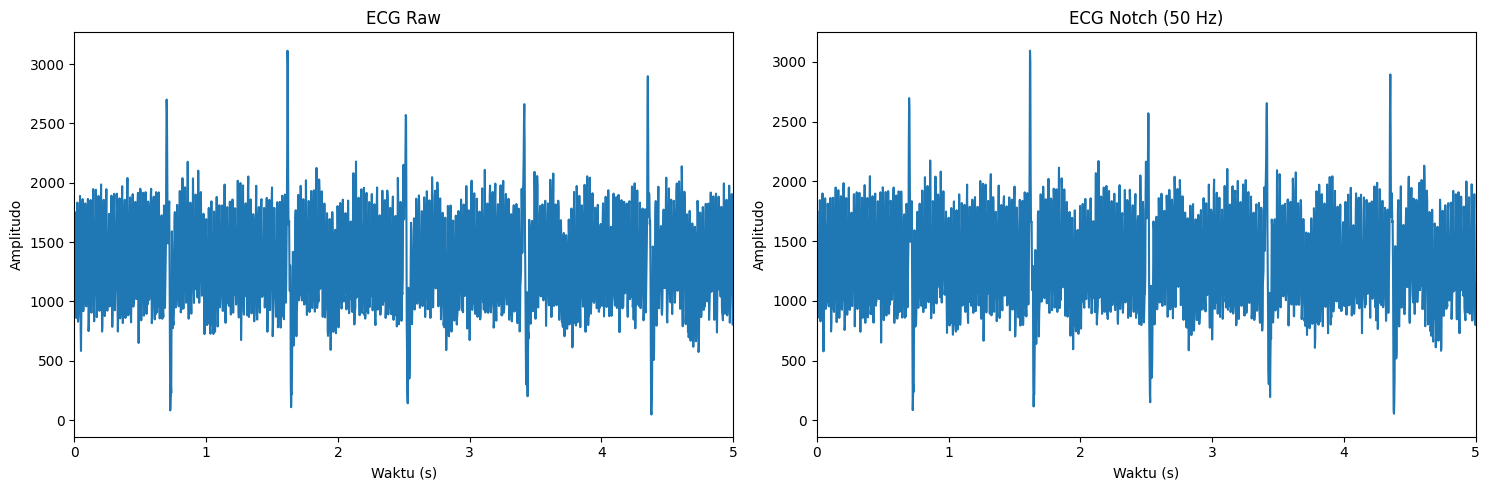

In [21]:
def downsample(x,time, fs, fs_target=125):
    num_samples = int(np.round((len(x) * fs_target / fs)))
    x_resample = resample(x, num_samples)
    time_resample = np.linspace(time[0], time[-1], num_samples)
    return x_resample, time_resample

def bandpass(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    x_clean = filtfilt(b, a, x)
    return x_clean

def notch(ecg, freq=50.0, fs=125, Q=30.0):
    nyq = 0.5 * fs
    if freq >= nyq:
        return ecg
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, ecg)

# ecg pipeline filtering
ecg_notch = notch(ecg)
ecg_resample, time_resample = downsample(ecg_notch,time,fs,125) 

fig, ax = plt.subplots(1,2,figsize=(15,5))
start = 0
end = 5

ax[0].plot(time,ecg)
ax[0].set_title('ECG Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].set_xlim(start, end)

ax[1].plot(time,ecg_notch)
ax[1].set_title('ECG Notch (50 Hz)')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].set_xlim(start, end)

plt.tight_layout()
plt.show()

Ekstraksi Fitur HR ECG

In [22]:

# 4. Hitung R peak
def calculate_mean_slope(signal, peak_idx, window_samples):
    """Menghitung rata-rata kemiringan (mean slope) 70 ms sebelum posisi peak_idx."""
    start_idx = max(0, peak_idx - window_samples)
    segment = signal[start_idx : peak_idx + 1]

    if len(segment) < 2:
        return 0.0

    # Kemiringan dihitung dari selisih absolut antar sampel berurutan
    slope = np.mean(np.abs(np.diff(segment)))
    return slope

def calculate_meansb(r_peaks, all_peaks, current_peak_idx, signal):
    """Menghitung MEANSB: Rata-rata amplitudo dari 3 QRS sebelumnya dan 3 puncak setelahnya."""
    # 1. Ambil amplitudo 3 QRS terakhir
    prev_qrs_vals = [signal[idx] for idx in r_peaks[-3:]] if r_peaks else []

    # 2. Cari indeks puncak setelah kandidat saat ini
    future_peaks = [idx for idx in all_peaks if idx > current_peak_idx]
    next_peak_vals = [signal[idx] for idx in future_peaks[:3]]

    # 3. Gabungkan seluruh sampel yang tersedia
    combined_vals = prev_qrs_vals + [signal[current_peak_idx]] + next_peak_vals

    return np.mean(combined_vals) if combined_vals else signal[current_peak_idx]

def rpeak(signal, fs=125):
    # 1. Bandpass Filter (5 - 18 Hz)
    ecg = bandpass(signal, 5.0, 18.0) 
    
    # 2. Diferensiasi Sinyal (5-Point Derivative)
    T = 1.0 / fs
    kernel = np.array([1, 2, 0, -2, -1]) * (1.0 / (8 * T))
    ecg_diff = np.convolve(ecg, kernel, mode='same')
    
    # 3. Pengkuadratan Titik demi Titik
    ecg_squared = ecg_diff ** 2

    # 4. Penghalusan (Flattop Window 60 ms)
    win_duration = 0.060 
    n_smooth = int(np.round(win_duration * fs))
    if n_smooth % 2 == 0: 
        n_smooth += 1  # Memastikan ukuran ganjil
    n = np.arange(n_smooth)
    psi = (2 * np.pi * n) / n_smooth
    a0, a1, a2, a3, a4 = (0.2155789, 0.4166316, 0.27726316, 0.08357895, 0.00694737)

    flatop_win = (a0 - a1 * np.cos(psi) + a2 * np.cos(2 * psi) - a3 * np.cos(3 * psi) + a4 * np.cos(4 * psi))
    flatop_win = flatop_win / np.sum(flatop_win)  # Normalisasi
    ecg_smoothed = np.convolve(ecg_squared, flatop_win, mode='same')

    # 5. Moving Window Integration (MWI 150 ms)
    mwi_win = 0.150
    n_mwi = int(np.round(mwi_win * fs))
    kernel_mwi = np.ones(n_mwi) / n_mwi
    ecg_mwi = np.convolve(ecg_smoothed, kernel_mwi, mode='same')

    # 6. Refractory Period (231 ms)
    refractory_period = 0.231
    min_distance = int(np.round(refractory_period * fs))
    r_peaks_index, _ = find_peaks(ecg_mwi, distance=min_distance)

    # 7. Inisialisasi Threshold (2 Detik Pertama)
    init_duration = 2.0
    init_sample = int(np.round(init_duration * fs))
    mwi_init = ecg_mwi[:init_sample]

    MAXF = np.max(mwi_init) if len(mwi_init) > 0 else np.max(ecg_mwi)
    MEANF = np.mean(mwi_init) if len(mwi_init) > 0 else np.mean(ecg_mwi)

    Threshold1 = MAXF / 3.0
    Threshold2 = 0.5 * MEANF

    spk = Threshold1
    npk = Threshold2
    th1 = Threshold1
    th2 = Threshold2

    # Sampel untuk Jendela Slope 70 ms
    N_70 = int(np.round(0.070 * fs))

    r_peaks = []
    noise_peaks = []

    # 8. Loop Decision Phase
    for peak_idx in r_peaks_index:
        peak_val = ecg_mwi[peak_idx]

        # Hitung RR-interval
        if len(r_peaks) > 0:
            last_r_idx = r_peaks[-1]
            current_rr_sec = (peak_idx - last_r_idx) / fs

            if len(r_peaks) >= 2:
                recent_r = r_peaks[-8:]
                mean_rr_sec = np.mean(np.diff(recent_r) / fs)
            else:
                mean_rr_sec = current_rr_sec
        else:
            current_rr_sec = 0.0
            mean_rr_sec = 0.0

        is_classified = False
        
        # --- Cabang 1: Evaluasi Puncak Normal ---
        if peak_val > th1:
            is_r_peak = True

            # Evaluasi Gelombang T (False Positive Check)
            if len(r_peaks) > 0 and (current_rr_sec < 0.360 or current_rr_sec < (0.5 * mean_rr_sec)):
                slope_curr = calculate_mean_slope(ecg_mwi, peak_idx, N_70)
                slope_prev = calculate_mean_slope(ecg_mwi, last_r_idx, N_70)

                if slope_curr < 0.60 * slope_prev:
                    is_r_peak = False  # Terdeteksi sebagai Gelombang T

            if is_r_peak:
                r_peaks.append(peak_idx)
                spk = 0.125 * peak_val + 0.875 * spk  # Rule-1 (SPK)
                is_classified = True
            else:
                noise_peaks.append(peak_idx)
                npk = 0.125 * peak_val + 0.875 * npk  # Rule-1 (NPK)
                is_classified = True

        # --- Cabang 2: Search-Back Mechanism ---
        elif len(r_peaks) > 0 and (current_rr_sec > 1.0 or current_rr_sec > (1.66 * mean_rr_sec)):
            meansb = calculate_meansb(r_peaks, r_peaks_index, peak_idx, ecg_mwi)
            th3 = 0.5 * th2 + 0.5 * meansb

            if peak_val > th3:
                r_peaks.append(peak_idx)
                spk = 0.75 * peak_val + 0.25 * spk  # Rule-2 (SPK)
                is_classified = True 

        # --- Cabang 3: Recovery dari Extreme High R-Peaks ---
        if not is_classified and len(r_peaks) > 0 and current_rr_sec > 1.4:
            if peak_val > (0.2 * th2):
                r_peaks.append(peak_idx)
                spk = 0.75 * peak_val + 0.25 * spk  # Rule-2 (SPK)
                is_classified = True

        # --- Cabang 4: Klasifikasi Puncak Kebisingan (Noise) ---
        if not is_classified:
            noise_peaks.append(peak_idx)
            npk = 0.125 * peak_val + 0.875 * npk  # Rule-1 (NPK)

        # --- Pembaruan Threshold Dinamis ---
        th1 = npk + 0.25 * (spk - npk)
        th2 = 0.4 * th1

    return r_peaks, noise_peaks

r_peaks, noise_peaks = rpeak(ecg_resample, 125)
print("r peaks:", len(r_peaks), "noise peaks:", len(noise_peaks))

def heart_rate(signal, fs=125):
    r_peaks, _ = rpeak(signal, fs)
    hr = 60.0 / np.mean(np.diff(r_peaks) / fs)
    return np.round(hr,2)

hr = heart_rate(ecg_resample)
print(f"Heart Rate: {hr} bpm")

r peaks: 66 noise peaks: 127
Heart Rate: 66.07 bpm


Ekstraksi Fitur RR ECG

In [23]:
def rr(ecg, r_peaks, fs=125):
    n_samples = len(ecg)
    total_seconds = n_samples / fs
    r_peaks = np.array(r_peaks)

    if len(r_peaks) < 4:
        return 0.0, np.zeros(n_samples), np.array([])

    T = 1.0 / fs
    kernel_diff = np.array([1, 2, 0, -2, -1]) * (1.0 / (8 * T))
    ecg_diff = np.convolve(ecg, kernel_diff, mode='same')
    win_samples = int(np.round(0.040 * fs))  # 40 ms
    edr_samples = []

    for idx in r_peaks:
        t0 = max(0, idx - win_samples)
        t1 = min(n_samples, idx + win_samples + 1)
        
        # Fitur EDR: Amplitudo turunan maksimum (kecuraman terkuat QRS)
        max_slope = np.max(np.abs(ecg_diff[t0:t1]))
        edr_samples.append(max_slope)

    edr_samples = np.array(edr_samples)
    xm = 0.0  # Running mean
    xd = 1.0  # Running absolute deviation
    xc = 0    # Counter detak

    r_signals = []
    for x in edr_samples:
        d = x - xm
        if xc < 500:
            xc += 1
            dn = d / xc
        else:
            dn = d / xc
            xdmax = 3.0 * xd / xc
            dn = np.clip(dn, -xdmax, xdmax)  # Kliping nilai ekstrem

        xm += dn
        xd += abs(dn) - xd / xc
        if xd < 1e-3: 
            xd = 1e-3

        r = d / xd
        r_signals.append(r)

    r_signals = np.array(r_signals)
    cs = CubicSpline(r_peaks, r_signals, extrapolate=False)
    
    # Membentuk rentang waktu kontinu dari puncak R pertama hingga terakhir
    interp_indices = np.arange(r_peaks[0], r_peaks[-1] + 1)
    resp_signal = cs(interp_indices)

    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1] + 1] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1] + 1:] = resp_signal[-1]

    min_distance_resp = int(np.round(1.6 * fs))
    resp_peaks, _ = find_peaks(
        resp_signal_full, 
        distance=min_distance_resp,
        height=np.mean(resp_signal_full)
    )

    b = len(resp_peaks)
    resp_rate = (b / (total_seconds / 60.0)) if total_seconds > 0 else 0.0

    return resp_rate, resp_signal_full, resp_peaks

resp_rate, resp_signal_full, resp_peaks = rr(ecg_resample, r_peaks)
print(f"Respiration Rate: {resp_rate:.2f} bpm")

Respiration Rate: 20.00 bpm


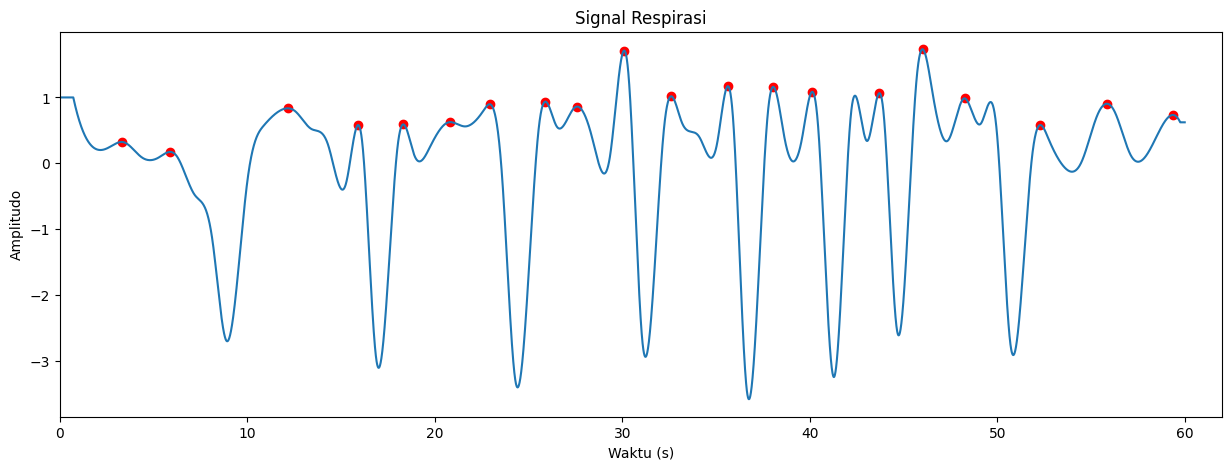

In [24]:
# validasi signal respiratory
start = 0
end = 62
plt.figure(figsize=(15,5))
plt.plot(time_resample, resp_signal_full)
plt.scatter(time_resample[resp_peaks], resp_signal_full[resp_peaks], color='r')
plt.title("Signal Respirasi")
plt.xlabel("Waktu (s)")
plt.ylabel("Amplitudo")
plt.xlim(start, end)
plt.show()

Filtering lanjutan untuk visualisasi / input model deep learning

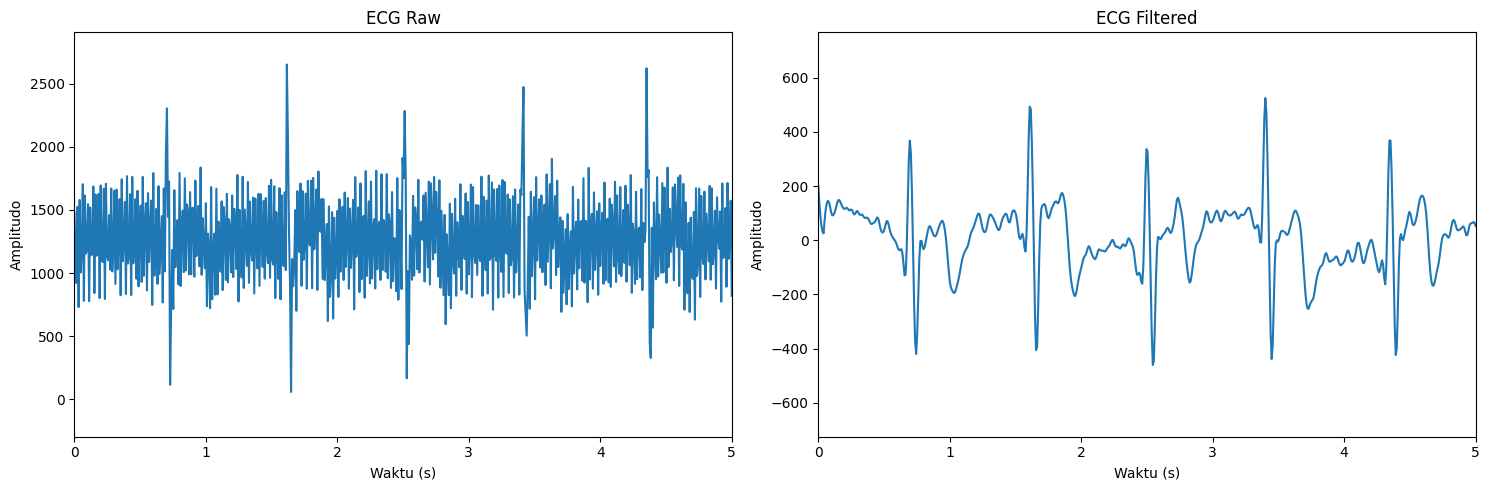

In [25]:
# detrending sinyal menggunakan double median filter
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter
def detrending(signal, fs=125):
    w1 = int(np.round(0.2 * fs))
    if w1 % 2 == 0:
        w1 += 1
    w2 = int(np.round(0.6 * fs))
    if w2 % 2 == 0:
        w2 += 1
    baseline_step1 = median_filter(signal, size=w1)
    baseline_step2 = median_filter(baseline_step1, size=w2)
    signal_detrended = signal - baseline_step2
    return signal_detrended

def savgol(signal, window_size=11, poly_order=2):
    smoothed_signal = savgol_filter(signal, window_size, poly_order)
    return smoothed_signal

def lowpass(signal, lowcut, fs):
    nyq = 0.5 * fs
    low = lowcut / nyq
    b, a = butter(3, low, btype='lowpass', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# untuk visualisasi / input deep learning
ecg_detrend = detrending(ecg_resample)
ecg_lpf = lowpass(ecg_detrend, 25, 125)
ecg_smooth = savgol(ecg_lpf) # sebagai acuan perhitungan SNR ecg nanti

start = 0
end = 5
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(time_resample,ecg_resample)
ax[0].set_title('ECG Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].set_xlim(start, end)

ax[1].plot(time_resample,ecg_smooth)
ax[1].set_title('ECG Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].set_xlim(start, end)
plt.tight_layout()
plt.show()


Processing PPG

In [26]:
def baseline_correction(time, x, fs=125):
    min_distance = int(0.5 * fs) 
    # Menggunakan prominence relatif terhadap standar deviasi sinyal
    prominence_thresh = 0.2 * np.std(x)
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=prominence_thresh)

    if len(peaks) < 2:
        # Fallback jika lembah terlalu sedikit
        baseline_dc = np.full_like(x, np.mean(x))
        return x - baseline_dc, np.abs(baseline_dc)
    
    t_val = time[peaks]
    s_val = x[peaks]

    # Mencegah edge effect dengan menyisipkan titik batas awal dan akhir
    if t_val[0] > time[0]:
        t_val = np.insert(t_val, 0, time[0])
        s_val = np.insert(s_val, 0, s_val[0])
    if t_val[-1] < time[-1]:
        t_val = np.append(t_val, time[-1])
        s_val = np.append(s_val, s_val[-1])

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    
    # Pastikan DC tidak nol atau negatif murni
    baseline_dc = np.maximum(np.abs(baseline_dc), 1e-6)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc

def ac_p2p(ac_signal, fs=125):
    min_distance = int(0.5 * fs)
    prominence_thresh = 0.2 * np.std(ac_signal)
    
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=prominence_thresh)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=prominence_thresh)
    
    if len(peaks) == 0 or len(troughs) == 0:
        return 0.0, peaks

    p2p_values = []
    # Memasangkan setiap peak dengan trough terdekat sebelum peak tersebut
    for p in peaks:
        valid_troughs = troughs[troughs < p]
        if len(valid_troughs) > 0:
            nearest_trough = valid_troughs[-1]
            amp = ac_signal[p] - ac_signal[nearest_trough]
            p2p_values.append(amp)
            
    if len(p2p_values) == 0:
        return 0.0, peaks

    return float(np.mean(p2p_values)), peaks

def Spo2(ac_ir, dc_ir, ac_red, dc_red):
    mean_dc_ir = np.mean(np.abs(dc_ir))
    mean_dc_red = np.mean(np.abs(dc_red))
    
    PI_red = ac_red / mean_dc_red
    PI_ir = ac_ir / mean_dc_ir

    R = PI_red / PI_ir
    spo2 = -17.8327 * (R**2) + (15.6006) * R + 94.6457
    spo2 = np.clip(spo2, 0, 100)
    return spo2, PI_red, PI_ir

In [27]:
red_resample, time_ppg_resample = downsample(red, time, fs, 125)
ir_resample, _ = downsample(ir, time, fs, 125)

# 1. Invert
red_resample = red_resample * -1
ir_resample = ir_resample * -1

# 2. Baseline Correction
red_corrected, dc_red = baseline_correction(time_ppg_resample, red_resample, fs=125)
ir_corrected, dc_ir = baseline_correction(time_ppg_resample, ir_resample, fs=125)

# 3. Bandpass Filtering (0.5 - 15 Hz)
red_bpf = bandpass(red_corrected, 0.5, 15, fs=125)
ir_bpf = bandpass(ir_corrected, 0.5, 15, fs=125)

# 4. Savitzky-Golay Smoothing
red_smooth = savgol(red_bpf, window_size=11, poly_order=2)
ir_smooth = savgol(ir_bpf, window_size=11, poly_order=2)

# 5. P2P
ac_red_amp, red_peaks = ac_p2p(red_smooth, fs=125)  
ac_ir_amp, ir_peaks = ac_p2p(ir_smooth, fs=125)    

# 6. Kalkulasi SpO2
spo2, PI_red, PI_ir = Spo2(ac_ir_amp, dc_ir, ac_red_amp, dc_red)

print(f"SpO2   : {spo2:.2f}%")
print(f"PI Red : {PI_red * 100:.2f}%")
print(f"PI IR  : {PI_ir * 100:.2f}%")

SpO2   : 98.06%
PI Red : 0.12%
PI IR  : 0.29%


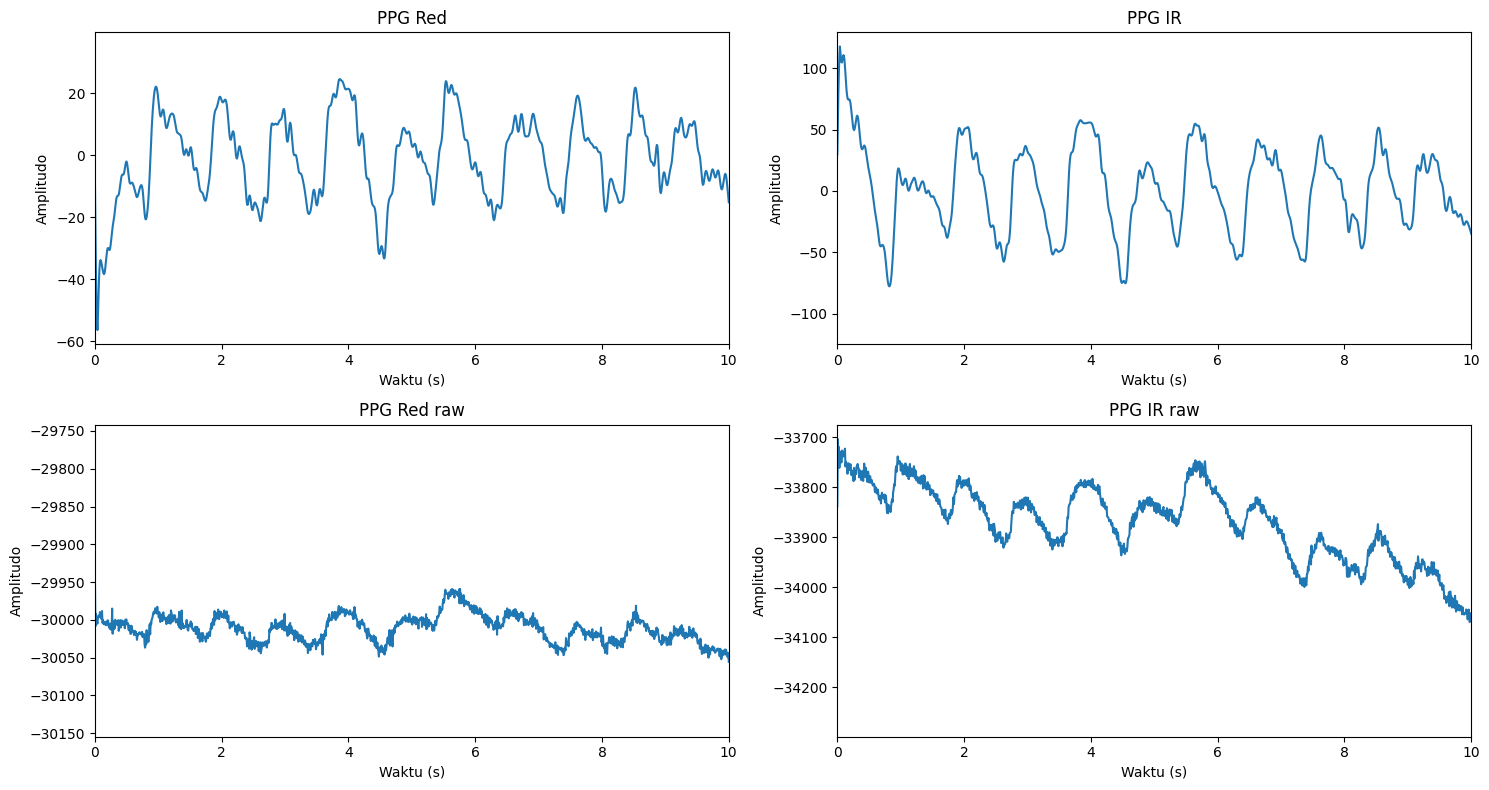

In [28]:
# plot smooth ppg
fig, ax = plt.subplots(2,2,figsize=(15,8))
ax = ax.flatten()
start = 0
end = 10

ax[0].plot(time_ppg_resample, red_smooth)
ax[0].set_title('PPG Red')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].set_xlim(start, end)

ax[1].plot(time_ppg_resample, ir_smooth)
ax[1].set_title('PPG IR')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].set_xlim(start, end)

ax[2].plot(time_ppg_resample, red_resample)
ax[2].set_title('PPG Red raw')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')
ax[2].set_xlim(start, end)

ax[3].plot(time_ppg_resample, ir_resample)
ax[3].set_title('PPG IR raw')
ax[3].set_xlabel('Waktu (s)')
ax[3].set_ylabel('Amplitudo')
ax[3].set_xlim(start, end)

plt.tight_layout()
plt.show()


Signal Qualityt Assesment

In [29]:
import scipy.signal as signal
def calculate_ppg_snr_psd(ppg_signal, fs, f_low=0.5, f_high=5.0, nperseg=None):
    """
    Menghitung SNR sinyal PPG menggunakan metode Power Spectral Density (Welch).
    
    Parameters:
    -----------
    ppg_signal : np.ndarray
        Array 1D sinyal PPG (raw atau bising).
    fs : float
        Frekuensi sampling dalam Hz (misal: 100 Hz, 250 Hz).
    f_low : float
        Batas bawah pita frekuensi sinyal PPG (default: 0.5 Hz = 30 BPM).
    f_high : float
        Batas atas pita frekuensi sinyal PPG (default: 5.0 Hz = 300 BPM, mencakup harmonik QRS/pulsa).
    nperseg : int, optional
        Panjang jendela FFT untuk metode Welch. Jika None, otomatis diset ~4 detik.
        
    Returns:
    --------
    snr_db : float
        Nilai SNR dalam desibel (dB).
    f : np.ndarray
        Array frekuensi dari estimasi PSD.
    psd : np.ndarray
        Nilai Power Spectral Density (V^2/Hz atau unit^2/Hz).
    """
    # Detrend sinyal global untuk menghilangkan komponen DC murni (0 Hz)
    ppg_detrended = signal.detrend(ppg_signal)
    
    # Set panjang jendela (window size) Welch method (~4 detik untuk resolusi ~0.25 Hz)
    if nperseg is None:
        nperseg = min(len(ppg_detrended), int(4 * fs))
        
    # 1. Hitung Power Spectral Density (PSD) menggunakan Welch Method
    f, psd = signal.welch(ppg_detrended, fs=fs, nperseg=nperseg)
    
    # 2. Buat Masking Pita Frekuensi Sinyal vs Noise
    signal_mask = (f >= f_low) & (f <= f_high)
    noise_mask = ~signal_mask
    
    # 3. Hitung Daya (Luas Area di Bawah Kurva PSD)
    df = f[1] - f[0]  # Resolusi frekuensi
    p_signal = np.sum(psd[signal_mask]) * df
    p_noise = np.sum(psd[noise_mask]) * df
    
    # Avoid division by zero
    if p_noise <= 0:
        return np.inf, f, psd
        
    # 4. Hitung SNR dalam dB
    snr_db = 10 * np.log10(p_signal / p_noise)
    
    return snr_db, f, psd

snr_db, f, psd = calculate_ppg_snr_psd(ir_bpf, fs=125, f_low=0.5, f_high=5.0, nperseg=None)
print(f"SNR dalam dB: {snr_db:.2f}")

SNR dalam dB: 14.12


In [30]:
import scipy.signal as signal
def calculate_snr_dual_signal(raw_ecg, filtered_ecg, r_peaks, fs, mode='isoelectric_hybrid'):
    """
    Menghitung SNR dengan menerima sinyal RAW dan FILTERED secara bersamaan.
    
    Parameters:
    -----------
    raw_ecg : np.ndarray
        Sinyal ECG mentah dari ADC/hardware.
    filtered_ecg : np.ndarray
        Sinyal ECG hasil filtering (BPF + Notch/SavGol).
    r_peaks : np.ndarray
        Array indeks R-peak (sebaiknya dideteksi dari filtered_ecg).
    fs : float
        Frekuensi sampling (Hz).
    mode : str
        'isoelectric_hybrid' -> Menggunakan Vpp QRS Filtered vs RMS TP Raw/Filtered.
        'residual'           -> Menggunakan varians (Filtered vs Selisih Raw-Filtered).
    """
    
    if mode == 'residual':
        # --- METODE 1: RESIDUAL (Raw - Filtered) ---
        noise = raw_ecg - filtered_ecg
        p_signal = np.var(filtered_ecg)
        p_noise = np.var(noise)
        
        snr_db = 10 * np.log10(p_signal / p_noise)
        return snr_db

    elif mode == 'isoelectric_hybrid':
        # --- METODE 2: HYBRID ISOELECTRIC ---
        qrs_amplitudes = []
        tp_rms_list = []
        
        win_qrs_pre = int(0.05 * fs)   # 50 ms sebelum R
        win_qrs_post = int(0.08 * fs)  # 80 ms setelah R
        
        tp_start_offset = int(0.25 * fs) # ~250 ms setelah R
        tp_end_offset = int(0.40 * fs)   # ~400 ms setelah R
        
        for r_curr in r_peaks:
            # 1. Ambil Amplitudo QRS (Vpp) dari FILTERED ECG (bebas spike noise)
            qrs_start = max(0, r_curr - win_qrs_pre)
            qrs_end = min(len(filtered_ecg), r_curr + win_qrs_post)
            
            qrs_seg = filtered_ecg[qrs_start:qrs_end]
            if len(qrs_seg) > 0:
                v_pp = np.ptp(qrs_seg)
                qrs_amplitudes.append(v_pp)
                
            # 2. Ambil Noise segmen TP dari RAW ECG 
            tp_start = r_curr + tp_start_offset
            tp_end = r_curr + tp_end_offset
            
            if tp_end < len(raw_ecg):
                tp_seg = raw_ecg[tp_start:tp_end]
                tp_seg_detrended = signal.detrend(tp_seg)
                rms = np.sqrt(np.mean(tp_seg_detrended**2))
                tp_rms_list.append(rms)
                
        if len(qrs_amplitudes) == 0 or len(tp_rms_list) == 0:
            return 0.0
            
        avg_vpp = np.mean(qrs_amplitudes)
        avg_tp_rms = np.mean(tp_rms_list)
        
        snr_db = 20 * np.log10(avg_vpp / (2 * np.sqrt(2) * avg_tp_rms))
        return snr_db

snr_db = calculate_snr_dual_signal(ecg_resample, ecg_smooth, r_peaks, fs=125, mode='isoelectric_hybrid')
print(f"SNR dalam dB: {snr_db:.2f}")

SNR dalam dB: 0.57


In [31]:
def detrending(signal, fs=125):
    w1 = int(np.round(0.2 * fs))
    if w1 % 2 == 0:
        w1 += 1
    w2 = int(np.round(0.6 * fs))
    if w2 % 2 == 0:
        w2 += 1
    baseline_step1 = median_filter(signal, size=w1)
    baseline_step2 = median_filter(baseline_step1, size=w2)
    signal_detrended = signal - baseline_step2
    return signal_detrended

def savgol(signal, window_size=11, poly_order=2):
    smoothed_signal = savgol_filter(signal, window_size, poly_order)
    return smoothed_signal

def lowpass(signal, lowcut, fs):
    nyq = 0.5 * fs
    low = lowcut / nyq
    b, a = butter(3, low, btype='lowpass', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

def downsample(x,time, fs, fs_target=125):
    num_samples = int(np.round((len(x) * fs_target / fs)))
    x_resample = resample(x, num_samples)
    time_resample = np.linspace(time[0], time[-1], num_samples)
    return x_resample, time_resample

def bandpass(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    x_clean = filtfilt(b, a, x)
    return x_clean

def notch(ecg, freq=50.0, fs=125, Q=30.0):
    nyq = 0.5 * fs
    if freq >= nyq:
        return ecg
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, ecg)